# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 PIPELINE: METRIC-REGULARIZED TRANSFORMER (Combined Arch) on: cuda
Loading Data/network_connections.csv...

--- PHASE A: ENGINEERING RICH FEATURES ---
1. NCA (Metric Learning)...
2. Isolation Forests...
3. Autoencoder...

--- PHASE B: TRAINING METRIC-TRANSFORMER ---
Epoch 5 | Loss: 0.2719 (CE+Trip+KoLeo)
Epoch 10 | Loss: 0.2282 (CE+Trip+KoLeo)
Epoch 15 | Loss: 0.1623 (CE+Trip+KoLeo)
Epoch 20 | Loss: 0.1297 (CE+Trip+KoLeo)

--- PHASE C: EVALUATION ---
✅ Best Thresholds found: R2L=0.01, U2R=0.05

👑 COMBINED MODEL RESULTS: 80.69% (MCC: 0.7183) 👑
              precision    recall  f1-score   support

         dos       0.97      0.80      0.87      7458
      normal       0.74      0.97      0.84      9711
       probe       0.78      0.71      0.74      2421
         r2l       0.80      0.36      0.50      2887
         u2r       0.45      0.54      0.49        67

    accuracy                           0.81     22544
   macro avg       0.75      0.68      0.69     22544
weighted avg    

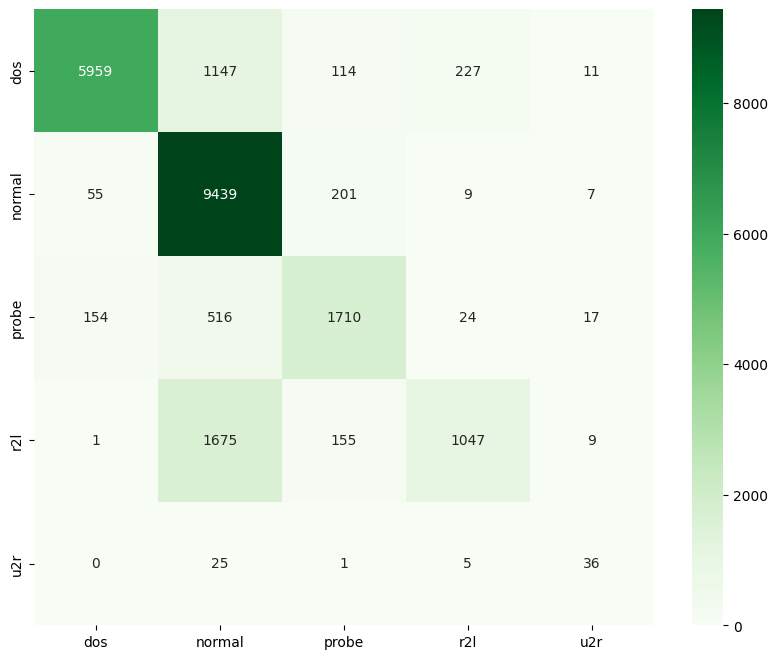

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 PIPELINE: METRIC-REGULARIZED TRANSFORMER (Combined Arch) on: {device}")

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

def load_and_prep(path):
    print(f"Loading {path}...")
    df = pd.read_csv(path)
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    if 'src_bytes' in df.columns:
        df['byte_ratio'] = (np.log1p(df['src_bytes'])) / (np.log1p(df['dst_bytes']) + 1)
        df['srv_diff'] = df['srv_count'] - df['count']
    
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])
            
    X = df.drop(['label', 'category'], axis=1).select_dtypes(include=[np.number])
    y = df['category']
    return X, y

# NOTE: Ensure you have your data file at this path
X, y = load_and_prep('Data/network_connections.csv')

le = LabelEncoder()
y_vec = le.fit_transform(y)
num_classes = len(le.classes_)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_vec, test_size=0.2, stratify=y_vec, random_state=42)
train_cols = X.columns.tolist()

del X, y
gc.collect()

# ==========================================
# 2. RICH FEATURE ENGINEERING (Shared Strength)
# ==========================================
print("\n--- PHASE A: ENGINEERING RICH FEATURES ---")
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw).astype(np.float32)

# 2.1 NCA (Metric Learning Feature)
print("1. NCA (Metric Learning)...")
nca = NeighborhoodComponentsAnalysis(n_components=15, random_state=42)
idx_sample = np.random.choice(len(X_train_sc), size=min(5000, len(X_train_sc)), replace=False)
nca.fit(X_train_sc[idx_sample], y_train[idx_sample])
X_train_nca = nca.transform(X_train_sc).astype(np.float32)

# 2.2 Isolation Forests (Anomaly Scores)
print("2. Isolation Forests...")
iso_models = {}
iso_feats_train = []
for cls_idx in np.unique(y_train):
    X_cls = X_train_sc[y_train == cls_idx]
    if len(X_cls) < 50: continue
    iso = IsolationForest(n_estimators=50, contamination=0.01, n_jobs=-1, random_state=42)
    iso.fit(X_cls)
    iso_models[cls_idx] = iso
    iso_feats_train.append(iso.decision_function(X_train_sc).reshape(-1, 1).astype(np.float32))
X_train_iso = np.hstack(iso_feats_train)

# 2.3 Autoencoder (Reconstruction Error)
print("3. Autoencoder...")
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x): return self.net(x)

ae = Autoencoder(X_train_sc.shape[1]).to(device)
ae_opt = optim.Adam(ae.parameters(), lr=0.005)
ae_loader = DataLoader(TensorDataset(torch.tensor(X_train_sc)), batch_size=512, shuffle=True)

for epoch in range(10):
    for batch in ae_loader:
        x = batch[0].to(device)
        loss = F.mse_loss(ae(x), x)
        ae_opt.zero_grad(); loss.backward(); ae_opt.step()

def get_recon_error_batched(data):
    ae.eval()
    loader = DataLoader(TensorDataset(torch.tensor(data)), batch_size=2048, shuffle=False)
    errors = []
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            recon = ae(x)
            err = torch.mean((x - recon)**2, dim=1).cpu().numpy()
            errors.append(err)
    return np.concatenate(errors).reshape(-1, 1).astype(np.float32)

X_train_ae = get_recon_error_batched(X_train_sc)

# Final Feature Concatenation
X_train_final = np.hstack([X_train_sc, X_train_nca, X_train_iso, X_train_ae])
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

del X_train_sc, X_train_nca, X_train_iso, X_train_ae
gc.collect()

# ==========================================
# 3. COMBINED ARCHITECTURE & LOSSES
# ==========================================

# --- A. The Backbone: Tabular ViT (From Arch 2) ---
class TabularPatchEmbed(nn.Module):
    def __init__(self, num_features, embed_dim):
        super().__init__()
        self.proj = nn.Parameter(torch.randn(num_features, embed_dim) / np.sqrt(embed_dim))
        self.bias = nn.Parameter(torch.zeros(num_features, embed_dim))
    def forward(self, x):
        return x.unsqueeze(-1) * self.proj.unsqueeze(0) + self.bias.unsqueeze(0)

class TransformerBackbone(nn.Module):
    def __init__(self, input_dim, embed_dim=128, depth=3, num_classes=5):
        super().__init__()
        self.patch_embed = TabularPatchEmbed(input_dim, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # Encoder Layer
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=4, dim_feedforward=256, 
            batch_first=True, norm_first=True, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=depth)
        
        # Heads
        self.embed_head = nn.Linear(embed_dim, 128) # For Triplet/KoLeo
        self.cls_head = nn.Linear(embed_dim, num_classes) # For Classification

    def forward(self, x):
        x_emb = self.patch_embed(x)
        b = x.shape[0]
        cls_tokens = self.cls_token.expand(b, -1, -1)
        x_seq = torch.cat((cls_tokens, x_emb), dim=1)
        
        # Pass through Transformer
        x_out = self.transformer(x_seq)
        cls_out = x_out[:, 0, :] # Extract CLS token
        
        # Returns: (Raw Features, Normalized Embedding, Logits)
        embedding = F.normalize(self.embed_head(cls_out), p=2, dim=1)
        logits = self.cls_head(cls_out)
        
        return cls_out, embedding, logits

# --- B. The Losses (Triplet from Arch 1 + KoLeo from Arch 2) ---

class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, embeddings, labels):
        dist_mat = torch.cdist(embeddings, embeddings)
        is_pos = labels.unsqueeze(0) == labels.unsqueeze(1)
        is_pos.fill_diagonal_(False)
        dist_pos = dist_mat.clone(); dist_pos[~is_pos] = -float('inf')
        hard_pos, _ = dist_pos.max(dim=1)
        is_neg = labels.unsqueeze(0) != labels.unsqueeze(1)
        dist_neg = dist_mat.clone(); dist_neg[~is_neg] = float('inf')
        hard_neg, _ = dist_neg.min(dim=1)
        return F.relu(hard_pos - hard_neg + self.margin).mean()

class KoLeoLoss(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, embeddings, eps=1e-8):
        # Embeddings should already be normalized
        dots = torch.mm(embeddings, embeddings.t())
        dots.view(-1)[::embeddings.shape[0]+1] = -float('inf')
        _, I = torch.max(dots, dim=1)
        nearest_neighbor = embeddings[I]
        dot_product = (embeddings * nearest_neighbor).sum(dim=1)
        return -torch.log(torch.sqrt(2 * (1 - dot_product + eps)) + eps).mean()

# ==========================================
# 4. TRAINING
# ==========================================

# Initialize Model
model = TransformerBackbone(input_dim=X_train_final.shape[1], embed_dim=128, num_classes=num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# Loss Definitions
crit_ce = nn.CrossEntropyLoss()
crit_triplet = BatchHardTripletLoss(margin=0.5)
crit_koleo = KoLeoLoss()

train_dl = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)

print("\n--- PHASE B: TRAINING METRIC-TRANSFORMER ---")
for epoch in range(20):
    model.train()
    loss_acc = 0
    
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        # Forward Pass
        _, embedding, logits = model(x)
        
        # Calculate Combined Loss
        l_ce = crit_ce(logits, y)            # Classification Accuracy
        l_trip = crit_triplet(embedding, y)  # Class Separation (Hard examples)
        l_kol = crit_koleo(embedding)        # Feature Space Uniformity
        
        # Weights: Emphasize Classification, but enforce structure via Triplet/KoLeo
        loss = l_ce + (0.5 * l_trip) + (0.1 * l_kol)
        
        loss.backward()
        optimizer.step()
        loss_acc += loss.item()
        
    scheduler.step()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss_acc/len(train_dl):.4f} (CE+Trip+KoLeo)")

# ==========================================
# 5. EVALUATION (MCC Optimized)
# ==========================================
print("\n--- PHASE C: EVALUATION ---")
# (Simplified Loading for Inference - Uses the same logic as previous)
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    if 'difficulty_level' in df_nsl.columns: df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    if 'src_bytes' in df_nsl.columns:
        df_nsl['byte_ratio'] = (np.log1p(df_nsl['src_bytes'])) / (np.log1p(df_nsl['dst_bytes']) + 1)
        df_nsl['srv_diff'] = df_nsl['srv_count'] - df_nsl['count']
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df_nsl.columns: df_nsl[c] = np.log1p(df_nsl[c])
            
    df_nsl_aligned = pd.DataFrame(0, index=np.arange(len(df_nsl)), columns=train_cols)
    for c in train_cols:
        if c in df_nsl.columns: df_nsl_aligned[c] = df_nsl[c]
    y_nsl_vec = df_nsl['category'].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values

    # Preprocess Test Data
    X_nsl_sc = scaler.transform(df_nsl_aligned).astype(np.float32)
    X_nsl_nca = nca.transform(X_nsl_sc).astype(np.float32)
    iso_feats_nsl = [iso_models[i].decision_function(X_nsl_sc).reshape(-1,1).astype(np.float32) for i in sorted(iso_models.keys())]
    X_nsl_iso = np.hstack(iso_feats_nsl)
    
    # AE Reconstruction
    with torch.no_grad():
        t_x = torch.tensor(X_nsl_sc).to(device)
        recon = ae(t_x)
        X_nsl_ae = torch.mean((t_x - recon)**2, dim=1).cpu().numpy().reshape(-1,1)
        
    X_nsl_final = np.hstack([X_nsl_sc, X_nsl_nca, X_nsl_iso, X_nsl_ae])
    X_test_tensor = torch.tensor(X_nsl_final, dtype=torch.float32)

    # Inference with TTA
    def predict(model, x_data):
        model.eval()
        loader = DataLoader(TensorDataset(x_data), batch_size=2048)
        probs = []
        with torch.no_grad():
            for bx in loader:
                bx = bx[0].to(device)
                _, _, logits = model(bx)
                probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        return np.concatenate(probs)

    probs_np = predict(model, X_test_tensor)

    # MCC Threshold Optimization (Critical for Intrusion Detection)
    idx_u2r = list(le.classes_).index('u2r')
    idx_r2l = list(le.classes_).index('r2l')
    best_mcc = -1
    best_params = (0, 0)
    
    # Simple search for best decision boundaries
    for t_r2l in [0.01, 0.05, 0.1, 0.2]:
        for t_u2r in [0.01, 0.05, 0.1, 0.2]:
            preds = []
            for p in probs_np:
                if p[idx_u2r] > t_u2r: preds.append(idx_u2r)
                elif p[idx_r2l] > t_r2l: preds.append(idx_r2l)
                else: preds.append(np.argmax(p))
            mask = y_nsl_vec != -1
            mcc = matthews_corrcoef(y_nsl_vec[mask], np.array(preds)[mask])
            if mcc > best_mcc:
                best_mcc = mcc
                best_params = (t_r2l, t_u2r)

    print(f"✅ Best Thresholds found: R2L={best_params[0]}, U2R={best_params[1]}")
    
    # Final Predictions
    final_preds = []
    t_r2l, t_u2r = best_params
    for p in probs_np:
        if p[idx_u2r] > t_u2r: final_preds.append(idx_u2r)
        elif p[idx_r2l] > t_r2l: final_preds.append(idx_r2l)
        else: final_preds.append(np.argmax(p))
    final_preds = np.array(final_preds)
    
    mask = y_nsl_vec != -1
    acc = accuracy_score(y_nsl_vec[mask], final_preds[mask])
    
    print("\n" + "="*40)
    print(f"👑 COMBINED MODEL RESULTS: {acc:.2%} (MCC: {best_mcc:.4f}) 👑")
    print("="*40)
    print(classification_report(y_nsl_vec[mask], final_preds[mask], target_names=le.classes_))
    
    labels = sorted(list(set(y_nsl_vec[mask]) | set(final_preds[mask])))
    label_names = [le.classes_[i] for i in labels]
    plt.figure(figsize=(10,8))
    sns.heatmap(confusion_matrix(y_nsl_vec[mask], final_preds[mask], labels=labels), 
                annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
    plt.show()

except Exception as e:
    print(f"Inference Error (Check data paths): {e}")